In [36]:
%matplotlib inline

In [2]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import yfinance as yf

from saber import metaLib as mtlib
from saber import PyFolio as pf
from saber import utilities as ut
from saber import mailer as mail

from saber import metaData as mtd
from saber import riskEngine as risk
from saber import PcEngine as pe
from saber import implementationEngine as ie
from saber import PyFolio as pyf
from saber import PerformanceAnalytics as pa
import os

import mt5plalib as plalb

mtw = mtlib.meta5_wrapper(login = 7933713,pw = '1523@Rocket')
PerfA = pa.PA(mtw)
rkm = risk.riskMgr(mtw)
mtd.data(mtw).update_tick_data()
mtd.data(mtw).update_trade_sized_close()

plalb.update_floating_pnl(PerfA,r"C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\discretionary_macro\floating_pnl")
plalb.update_realized_pnl(PerfA,r"C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\discretionary_macro\realized_pnl")
plalb.update_portfolio_var(rkm,r"C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\discretionary_macro\var")
pnl_df = plalb.build_pnl_from_files(r"C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\discretionary_macro")
var_ts = -plalb.build_var_timeseries(r"C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\discretionary_macro\var")
plalb.send_dgm_summary_email(pnl_df, var_ts, mtw, 'kmavyrle@gmail.com')

VIX_F6  download failed
VIX_G6  download failed
VIX_J6  download failed
VIX_K6  download failed
VIX_M6  download failed
VIX_N6  download failed
VIX_Q6  download failed
VIX_U6  download failed
VIX_V6  download failed
VIX_X6  download failed
VIX_Z6  download failed
UST30Y_H6  download failed
Saved: floating_pnl_2026-03-03.csv
Error on 2026-01-01: "None of [Index(['2026-01-01'], dtype='object', name='Date')] are in the [index]" - skipping
Error on 2026-01-02: "None of [Index(['2026-01-02'], dtype='object', name='Date')] are in the [index]" - skipping
Error on 2026-01-03: "None of [Index(['2026-01-03'], dtype='object', name='Date')] are in the [index]" - skipping
Error on 2026-01-04: "None of [Index(['2026-01-04'], dtype='object', name='Date')] are in the [index]" - skipping
Error on 2026-01-05: "None of [Index(['2026-01-05'], dtype='object', name='Date')] are in the [index]" - skipping
Error on 2026-01-06: "None of [Index(['2026-01-06'], dtype='object', name='Date')] are in the [index]" -

In [3]:
# Usage:
mtw = mtlib.meta5_wrapper()
PerfA = pa.PA(mtw)
rkm = risk.riskMgr(mtw)
plalb.update_floating_pnl(PerfA,r"C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\systematic\floating_pnl")
plalb.update_realized_pnl(PerfA,r"C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\systematic\realized_pnl")
plalb.update_portfolio_var(rkm,r"C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\systematic\var",wdw = 20)
pnl_df = plalb.build_pnl_from_files(r'C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\systematic')



pnl_df.index = pd.to_datetime(pnl_df.index,format = 'mixed',dayfirst= True)
#pnl_df = pnl_df[~pnl_df.index.duplicated(keep='first')]
pnl_df = pnl_df.sort_index().fillna(0)#.cumsum()
var_ts = plalb.build_var_timeseries(r'C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\systematic\var')
plalb.send_dgm_summary_email(pnl_df, var_ts, mtw, 'kmavyrle@gmail.com')

Saved: floating_pnl_2026-03-03.csv
Already exists: realized_pnl_2026-01-01.csv - skipping
Already exists: realized_pnl_2026-01-02.csv - skipping
Already exists: realized_pnl_2026-01-03.csv - skipping
Error on 2026-01-04: "None of [Index(['2026-01-04'], dtype='object', name='Date')] are in the [index]" - skipping
No realized trades on 2026-01-05 - skipping
Already exists: realized_pnl_2026-01-06.csv - skipping
Already exists: realized_pnl_2026-01-07.csv - skipping
Already exists: realized_pnl_2026-01-08.csv - skipping
Error on 2026-01-09: "None of [Index(['2026-01-09'], dtype='object', name='Date')] are in the [index]" - skipping
Already exists: realized_pnl_2026-01-10.csv - skipping
Error on 2026-01-11: "None of [Index(['2026-01-11'], dtype='object', name='Date')] are in the [index]" - skipping
Already exists: realized_pnl_2026-01-12.csv - skipping
Error on 2026-01-13: "None of [Index(['2026-01-13'], dtype='object', name='Date')] are in the [index]" - skipping
Already exists: realized_

In [236]:
import pandas as pd
import os
import glob

# --- Load Realized PnL ---
realized_dir = r"C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\systematic\realized_pnl"
realized_dfs = []
for f in sorted(glob.glob(os.path.join(realized_dir, '*.csv'))):
    df = pd.read_csv(f, index_col='Date')
    df.drop(columns='TOTAL', errors='ignore', inplace=True)
    df.index = pd.to_datetime(df.index, format='mixed', dayfirst=True).strftime('%Y-%m-%d')
    realized_dfs.append(df)
realized_combined = pd.concat(realized_dfs, axis=0, join='outer').fillna(0)
realized_combined = realized_combined.groupby(realized_combined.index).sum()
# --- Cumsum realized (missing dates contribute 0, carry forward) ---
realized_combined = realized_combined.reindex(index=all_dates, columns=all_cols, fill_value=0).sort_index()

In [49]:
import pandas as pd
import os
import glob

# --- Load Realized PnL ---
realized_dir = r"C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\systematic\realized_pnl"
realized_dfs = []
for f in sorted(glob.glob(os.path.join(realized_dir, '*.csv'))):
    df = pd.read_csv(f, index_col='Date')
    df.drop(columns='TOTAL', errors='ignore', inplace=True)
    df.index = pd.to_datetime(df.index, format='mixed', dayfirst=True).strftime('%Y-%m-%d')
    realized_dfs.append(df)

realized_combined = pd.concat(realized_dfs, axis=0, join='outer').fillna(0)
realized_combined = realized_combined.groupby(realized_combined.index).sum()

# --- Load Floating PnL ---
floating_dir = r"C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\systematic\floating_pnl"
floating_dfs = []
for f in sorted(glob.glob(os.path.join(floating_dir, '*.csv'))):
    df = pd.read_csv(f, index_col='Date')
    df.drop(columns='TOTAL', errors='ignore', inplace=True)
    df.index = pd.to_datetime(df.index, format='mixed', dayfirst=True).strftime('%Y-%m-%d')
    floating_dfs.append(df)

floating_combined = pd.concat(floating_dfs, axis=0, join='outer').fillna(0)
floating_combined = floating_combined.groupby(floating_combined.index).sum()

# --- Align dates and columns ---
all_dates = sorted(set(realized_combined.index.tolist() + floating_combined.index.tolist()))
all_cols = list(set(realized_combined.columns.tolist() + floating_combined.columns.tolist()))

# --- Cumsum realized (missing dates contribute 0, carry forward) ---
realized_combined = realized_combined.reindex(index=all_dates, columns=all_cols, fill_value=0).sort_index()
realized_cumulative = realized_combined.cumsum()

# --- Ffill floating (carry forward last known snapshot) ---
floating_combined = floating_combined.reindex(index=all_dates, columns=all_cols).sort_index().ffill().fillna(0)

# --- Total PnL = cumulative realized + current floating ---
pnl = realized_cumulative + floating_combined
pnl['TOTAL'] = pnl.sum(axis=1)
pnl = pnl[~pnl.index.duplicated(keep='first')]
pnl

,STOXX50,SNOW.NYSE,ONTO.NYSE,BTCUSD,CHINA50,SCCO.NYSE,SOLUSD,USDMXN,TWLO.NYSE,XLU.NYSE,...,ETHUSD,PYPL.NAS-24,AUS200,TLT.NAS,XLI.NYSE,USDJPY,XBRUSD,EURUSD,AMZN.NAS-24,TOTAL
Date,,,,,,,,,,,,,,,,,,,,,
2026-01-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-7.94,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,10.37,0.00,0.00,0.00,2.43
2026-01-02,0.00,0.00,0.00,0.00,336.74,0.00,0.00,-7.94,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,-15.97,0.00,0.00,0.00,312.83
2026-01-03,0.00,0.00,0.00,0.00,339.05,0.00,0.00,-7.94,0.00,0.00,...,4.02,0.00,0.00,0.00,0.00,-115.85,0.00,0.00,0.00,219.28
2026-01-06,0.00,0.00,0.00,0.00,575.39,0.00,0.00,-7.94,0.00,0.00,...,11.37,0.00,0.00,0.00,0.00,-208.94,0.00,5.99,0.00,372.07
2026-01-07,0.00,0.00,0.00,0.00,339.92,0.00,0.00,-7.94,0.00,0.00,...,9.91,0.00,0.00,0.00,0.00,-258.03,0.00,5.99,0.00,85.77
2026-01-08,0.00,0.00,0.00,0.00,124.72,0.00,0.00,-7.94,0.00,0.00,...,9.91,0.00,0.00,0.00,0.00,-464.30,0.00,5.99,0.00,-335.70
2026-01-10,0.00,0.00,0.00,0.00,124.72,0.00,0.00,-7.94,0.00,0.00,...,9.91,0.00,0.00,0.00,0.00,-464.30,0.00,5.99,0.00,-309.11
2026-01-12,0.00,0.00,0.00,0.00,156.72,0.00,0.00,-7.94,0.00,0.00,...,9.91,0.00,0.00,0.00,0.00,-461.57,0.00,5.99,0.00,-274.38
2026-01-14,0.00,0.00,0.00,0.00,156.72,0.00,0.00,-7.94,0.00,0.00,...,9.91,0.00,0.00,0.00,0.00,-572.84,0.00,5.99,0.00,-385.65


In [63]:

#import yfinance as yf
import numpy as np
import datetime
import pandas as pd

from saber import PyFolio as pf
from saber import utilities as ut
from saber import mailer as mail
from saber import metaLib as mtlib
from saber import metaData as mtd
from saber import riskEngine as risk
from saber import PcEngine as pe
from saber import implementationEngine as ie


mtw = mtlib.meta5_wrapper()

def volume_transform(volume):
    volume = volume.pct_change()
    vol_pointer = [1 if v>0.2 else np.nan for v in volume]
    vol_pointer = pd.Series(vol_pointer)
    vol = [1.5 if v==1 else 0.5 for v in vol_pointer]
    #print(vol_pointer.tail(60))
    volume = pd.Series(vol,index = volume.index)
    #volume = (volume/(abs(volume).sum()))*len(volume)
    return volume


def get_usdjpy_signal():
    dt_now = datetime.datetime.now()+datetime.timedelta(hours=9)
    yen = mtw.get_tick_data("USDJPY",periodicity='1h',timeframe=  24000,end_dt = dt_now)
    yen['volume'] = volume_transform(yen['tick_volume'])
    yen['sma1'] = yen['close'].rolling(window=1).mean()
    yen['sma24'] = yen['close'].rolling(window=24).mean()
    yen['vol'] = yen['close'].diff().rolling(5).std()
    yen['signal'] = np.where(yen['sma1'] > yen['sma24'], 1, -1)
    yen['signal'] = yen['signal']*yen['volume']
    return yen
    #return yen
    sig = yen.signal.iloc[-1]
    var_multiplier = yen.volume.iloc[-1]
    
    return float(sig),float(var_multiplier)

def get_usdjpy_pos(var_target = 250):
    sig,var_multiplier = get_usdjpy_signal()
    pos = ie.execution().get_default_zero_pos()
    pos['USDJPY'] = sig
    
    var = risk.riskMgr().get_pos_theoretical_var(pos)
    
    sig = (sig*var_target*var_multiplier)/var
    sig = round(sig/0.01)*0.01
    pos['USDJPY'] = sig
    
    return pos

In [51]:
symbols = ['XRPUSD', 'BTCUSD', 'ETHUSD', 'SOLUSD', "VETUSD",'DOGUSD',"XTZUSD","XLMUSD","ADAUSD","MATICUSD","AVAXUSD","ADAUSD"]

prices = {}
for sym in symbols:
    try:
        df = mtw.get_tick_data(sym, periodicity='1h', timeframe=10000)
        prices[sym] = df['close']
        print(f"{sym}: OK — latest {df['close'].iloc[-1]:.4f} @ {df.index[-1]}")
    except Exception as e:
        print(f"{sym}: FAILED — {e}")

prices = pd.DataFrame(prices)
prices

XRPUSD: OK — latest 1.4077 @ 2026-03-02 18:00:00
BTCUSD: OK — latest 69446.2600 @ 2026-03-02 18:00:00
ETHUSD: OK — latest 2063.5300 @ 2026-03-02 18:00:00
SOLUSD: OK — latest 88.8420 @ 2026-03-02 18:00:00
VETUSD: OK — latest 0.0074 @ 2026-03-02 18:00:00
DOGUSD: OK — latest 0.0950 @ 2026-03-02 18:00:00
XTZUSD: OK — latest 0.3795 @ 2026-03-02 18:00:00
XLMUSD: OK — latest 0.1578 @ 2026-03-02 18:00:00
ADAUSD: OK — latest 0.2836 @ 2026-03-02 18:00:00
MATICUSD: FAILED — 'time'
AVAXUSD: FAILED — 'time'
ADAUSD: OK — latest 0.2836 @ 2026-03-02 18:00:00


,XRPUSD,BTCUSD,ETHUSD,SOLUSD,VETUSD,DOGUSD,XTZUSD,XLMUSD,ADAUSD
Date,,,,,,,,,
2024-12-29 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.35314,NaN
2024-12-29 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.35072,NaN
2024-12-29 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.35255,NaN
2024-12-29 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.35402,NaN
2024-12-29 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.35249,NaN
...,...,...,...,...,...,...,...,...,...
2026-03-02 14:00:00,1.3475,65939.57,1936.03,83.6600,0.00708,0.09011,0.3655,0.15149,0.2698
2026-03-02 15:00:00,1.3391,65424.26,1925.64,83.0275,0.00705,0.08961,0.3665,0.15119,0.2689
2026-03-02 16:00:00,1.3729,67161.83,1978.17,85.6565,0.00726,0.09227,0.3765,0.15529,0.2760


XRPUSD: OK — latest 1.4077 @ 2026-03-02 18:00:00
BTCUSD: OK — latest 69446.2600 @ 2026-03-02 18:00:00
ETHUSD: OK — latest 2063.5300 @ 2026-03-02 18:00:00
SOLUSD: OK — latest 88.8420 @ 2026-03-02 18:00:00
VETUSD: OK — latest 0.0074 @ 2026-03-02 18:00:00
DOGUSD: OK — latest 0.0950 @ 2026-03-02 18:00:00
XTZUSD: OK — latest 0.3795 @ 2026-03-02 18:00:00
XLMUSD: OK — latest 0.1578 @ 2026-03-02 18:00:00
ADAUSD: OK — latest 0.2836 @ 2026-03-02 18:00:00
ADAUSD: OK — latest 0.2836 @ 2026-03-02 18:00:00


C:\Users\kmavy\AppData\Local\Temp\ipykernel_3264\1391938172.py:21: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  (signal.shift(23)*prices.pct_change()).cumsum().sum(axis = 1).plot()


<Axes: xlabel='Date'>

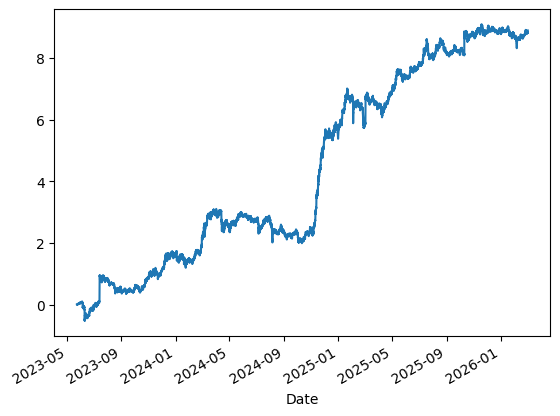

In [52]:
symbols = ['XRPUSD', 'BTCUSD', 'ETHUSD', 'SOLUSD', "VETUSD",'DOGUSD',"XTZUSD","XLMUSD","ADAUSD","ADAUSD"]

prices = {}
for sym in symbols:
    try:
        df = mtw.get_tick_data(sym, periodicity='1h', timeframe=24000)
        prices[sym] = df['close']
        print(f"{sym}: OK — latest {df['close'].iloc[-1]:.4f} @ {df.index[-1]}")
    except Exception as e:
        print(f"{sym}: FAILED — {e}")

prices = pd.DataFrame(prices)
prices
rank = (prices/prices.shift(1))-1
#rank
N = len(symbols)
rank = rank.rank(axis=1, method='min', ascending=True)
count = 2
signal  = np.where(rank <= count, 1, np.where(rank >= N-count+1, -1, 0))
signal = pd.DataFrame(signal,index = rank.index, columns = rank.columns)
(signal.shift(23)*prices.pct_change()).cumsum().sum(axis = 1).plot()

In [53]:
import pytz
def get_btcusd_signal():
    dt_now = datetime.datetime.now()+datetime.timedelta(hours = 2)#
    #print(dt_now)
    #dt_now = datetime.datetime.now(pytz.timezone("Etc/GMT-3"))
    yen = mtw.get_tick_data("BTCUSD",periodicity='1h',timeframe=  72,end_dt = dt_now)
    yen['volume'] = volume_transform(yen['tick_volume'])
    yen['sma1'] = yen['close'].rolling(window=1).mean()
    yen['sma24'] = yen['close'].rolling(window=24).mean()
    yen['vol'] = yen['close'].diff().rolling(5).std()
    yen['signal'] = np.where(yen['sma1'] > yen['sma24'], 1, -1)
    yen['signal'] = yen['signal']*yen['volume']
    return yen

In [54]:
get_usdjpy_signal()

,open,high,low,close,tick_volume,spread,real_volume,asset,volume,sma1,sma24,vol,signal
Date,,,,,,,,,,,,,
2022-04-28 00:00:00,128.418,128.490,128.398,128.473,1830,3,0,USDJPY,0.5,128.473,NaN,NaN,-0.5
2022-04-28 01:00:00,128.477,128.552,128.341,128.521,1846,0,0,USDJPY,0.5,128.521,NaN,NaN,-0.5
2022-04-28 02:00:00,128.522,128.554,128.390,128.447,2009,0,0,USDJPY,0.5,128.447,NaN,NaN,-0.5
2022-04-28 03:00:00,128.445,128.846,128.353,128.818,5139,0,0,USDJPY,1.5,128.818,NaN,NaN,-1.5
2022-04-28 04:00:00,128.820,128.895,128.663,128.703,4639,0,0,USDJPY,0.5,128.703,NaN,NaN,-0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-06 19:00:00,157.642,157.855,157.600,157.802,6120,0,0,USDJPY,0.5,157.802,157.681875,0.146797,0.5
2026-03-06 20:00:00,157.802,157.877,157.616,157.812,5538,0,0,USDJPY,0.5,157.812,157.685292,0.138605,0.5
2026-03-06 21:00:00,157.811,157.876,157.750,157.876,4027,0,0,USDJPY,0.5,157.876,157.687875,0.088350,0.5


In [55]:

from zoneinfo import ZoneInfo
tz = ZoneInfo("Etc/GMT-2")
temp = get_btcusd_signal()
temp.index = temp.index.tz_localize(tz).tz_convert("Asia/Singapore")
temp

,open,high,low,close,tick_volume,spread,real_volume,asset,volume,sma1,sma24,vol,signal
Date,,,,,,,,,,,,,
2026-03-05 00:00:00+08:00,73399.17,73536.73,72536.07,73309.94,31989,1200,0,BTCUSD,0.5,73309.94,NaN,NaN,-0.5
2026-03-05 01:00:00+08:00,73310.04,73796.53,72937.38,73239.94,29815,1200,0,BTCUSD,0.5,73239.94,NaN,NaN,-0.5
2026-03-05 02:00:00+08:00,73239.94,73767.79,72914.57,73728.87,24863,1200,0,BTCUSD,0.5,73728.87,NaN,NaN,-0.5
2026-03-05 03:00:00+08:00,73729.44,74111.80,73497.27,73650.62,27394,1200,0,BTCUSD,0.5,73650.62,NaN,NaN,-0.5
2026-03-05 04:00:00+08:00,73650.58,73770.93,73071.39,73071.39,22848,1200,0,BTCUSD,0.5,73071.39,NaN,NaN,-0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-07 19:00:00+08:00,67874.98,68234.53,67818.52,68000.29,10873,1200,0,BTCUSD,1.5,68000.29,68232.324167,135.783812,-1.5
2026-03-07 20:00:00+08:00,68000.29,68077.90,67879.74,67976.79,8708,1200,0,BTCUSD,0.5,67976.79,68151.607083,130.533315,-0.5
2026-03-07 21:00:00+08:00,67976.76,68068.76,67793.75,67918.81,9256,1200,0,BTCUSD,0.5,67918.81,68097.733750,132.220388,-0.5


In [11]:
tick = mtw.mt5.symbol_info_tick("BTCUSD")
import datetime
#tick = mtw.mt5.symbol_info_tick("USDJPY")
broker_time = datetime.datetime.utcfromtimestamp(tick.time)
mytimenow = datetime.datetime.now()
offset = round((broker_time - mytimenow).total_seconds() / 3600)
print(broker_time)
#print(f"Broker offset: UTC+{offset}")

2026-03-02 20:33:01


In [56]:
dollyen_realized = PerfA.get_trade_hist()
dollayenrlsd = dollyen_realized[dollyen_realized['symbol'] == 'USDJPY']
dollayenrlsd

,ticket,order,date,date_msc,type,entry,magic,position_id,reason,volume,price,commission,swap,profit,fee,symbol,comment,external_id
2025-11-05,804899310,857455594,1762287830,1762287830487,0,0,123456,857455594,3,0.21,153.582,0.0,0.00,0.00,0.0,USDJPY,,3664404923
2025-11-05,805204796,857818533,1762334075,1762334075453,1,1,123456,857455594,3,0.01,153.540,0.0,0.11,-0.36,0.0,USDJPY,,3665434095
2025-11-05,805289960,857914944,1762344029,1762344029510,0,0,123456,857914944,3,0.01,153.699,0.0,0.00,0.00,0.0,USDJPY,,3665739464
2025-11-05,805303482,857929154,1762344935,1762344935165,1,1,123456,857455594,3,0.01,153.779,0.0,0.11,1.67,0.0,USDJPY,,3665791291
2025-11-05,805303488,857929160,1762344935,1762344935411,1,1,123456,857914944,3,0.01,153.779,0.0,0.00,0.68,0.0,USDJPY,,3665791304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-07,878660945,4376305187,1772824481,1772824481280,0,0,123456,4376305187,3,0.16,157.703,0.0,0.00,0.00,0.0,USDJPY,,3902289160
2026-03-07,878702725,4376354017,1772828122,1772828122620,1,1,123456,4376305187,3,0.16,157.648,0.0,0.00,-7.14,0.0,USDJPY,,3902428032
2026-03-07,878702726,4376354018,1772828122,1772828122955,1,0,123456,4376354018,3,0.16,157.649,0.0,0.00,0.00,0.0,USDJPY,,3902428039
2026-03-07,878708135,4376360156,1772828735,1772828735846,0,1,123456,4376354018,3,0.16,157.716,0.0,0.00,-8.69,0.0,USDJPY,,3902444597


In [57]:

dlr = dollayenrlsd.copy()
dlr['signed_vol'] = dlr['volume'] * dlr['type'].map({0: 1, 1: -1})
dlr['ts'] = pd.to_datetime(dlr['date'], unit='s')
dlr = dlr.groupby('ts')[['signed_vol', 'profit','price']].sum()
dlr['signed_vol'] = dlr['signed_vol'].cumsum()
dlr['signed_vol'] =  dlr["signed_vol"].map(lambda x: f"{x:.6f}")
dlr['signed_vol'] = dlr['signed_vol'].astype(float)
dlr['traded_signal'] = dlr['signed_vol']#
#dlr
yen_full = get_usdjpy_signal()
yen2 = yen_full.copy()
yen2['signal'] = yen2['signal'].shift()#.fillna(0)
yen2 = yen2[['signal','close']]
combined = pd.concat([dlr, yen2], axis=1, join='outer').sort_index().ffill().dropna()
combined['signalchg'] = combined['signed_vol'].diff()
combined['dir_chg'] = [1 if s != 0  else 0 for s in combined['signalchg']]
#combined.corr()

is_hour    = (combined.index.minute == 0) & (combined.index.second == 0)
has_trade  = combined['dir_chg'] != 0

ccombined = combined[is_hour | has_trade]


In [42]:
%matplotlib inline

<Axes: >

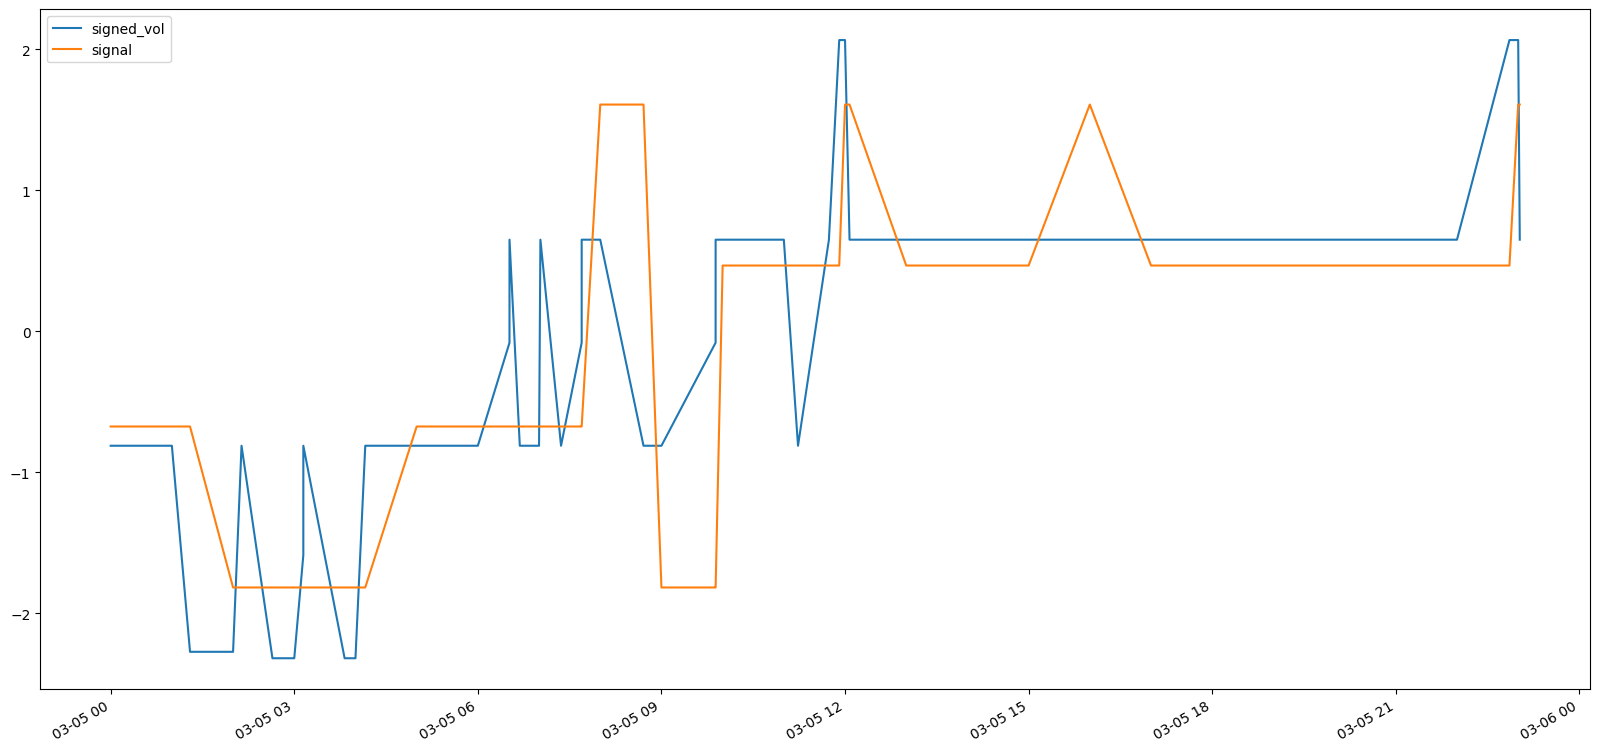

In [62]:
temp = combined[['signed_vol','signal']]#.plot(figsize = (20,10))
temp = (temp - temp.mean()) / temp.std()
temp.loc["2026-03-05"].plot(figsize = (20,10))

In [44]:
import datetime
tick = mtw.mt5.symbol_info_tick("BTCUSD")
broker_time = datetime.datetime.utcfromtimestamp(tick.time) + datetime.timedelta(hours=3)
local_now   = datetime.datetime.now()

print(f"Broker time: {broker_time}")
print(f"Local now:   {local_now}")
print(f"Difference:  {local_now - broker_time}")

Broker time: 2026-03-07 20:52:14
Local now:   2026-03-07 23:52:12.741198
Difference:  2:59:58.741198


In [45]:
tick

Tick(time=1772905934, bid=67840.18, ask=67852.18, last=0.0, volume=0, time_msc=1772905934282, flags=6, volume_real=0.0)

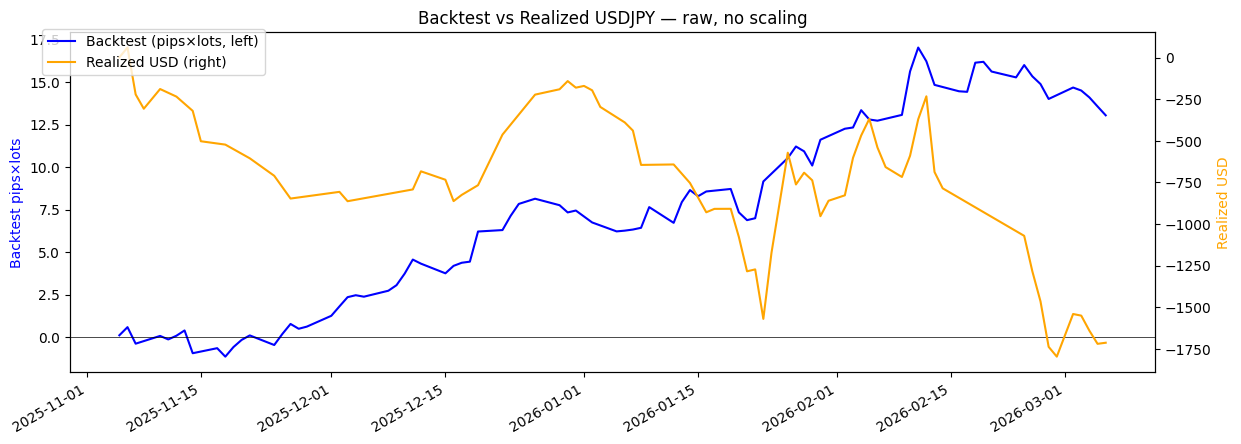

Backtest daily sample (pips×lots):
2026-02-23   -0.3440
2026-02-24    0.7245
2026-02-25   -0.6615
2026-02-26   -0.4540
2026-02-27   -0.8770
2026-03-02    0.6720
2026-03-03   -0.1765
2026-03-04   -0.4060
2026-03-05   -0.5300
2026-03-06   -0.5215

Realized daily sample (USD):
2026-02-24   -285.64
2026-02-25   -213.14
2026-02-26   -180.52
2026-02-27   -273.34
2026-02-28    -58.92
2026-03-02    256.19
2026-03-03     -9.74
2026-03-04    -90.73
2026-03-05    -78.76
2026-03-06      6.57


In [46]:
# === Backtest vs Realized USDJPY ===

# ── Backtest: signal.shift(1) * close.diff(), summed daily ──
yen_full = get_usdjpy_signal()
bt_daily = (yen_full['signal'].shift(1) * yen_full['close'].diff()).groupby(yen_full.index.date).sum()
bt_daily.index = pd.to_datetime(bt_daily.index)

# ── Realized: actual profit+swap from closed USDJPY trades ──
dlr = dollayenrlsd.copy()
dlr.index = pd.to_datetime(dlr.index)
closes = dlr[dlr['entry'] == 1]
rd_daily = closes.groupby(closes.index)[['profit','swap']].sum().sum(axis=1)

# ── Align ──
start = max(bt_daily.index.min(), rd_daily.index.min())
end   = min(bt_daily.index.max(), rd_daily.index.max())
bt = bt_daily[start:end]
rd = rd_daily[start:end]

# ── Plot both cumulative (dual axis so units don't matter) ──
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
bt.cumsum().plot(ax=ax1, color='blue',  label='Backtest (pips×lots, left)')
rd.cumsum().plot(ax=ax2, color='orange', label='Realized USD (right)')
ax1.set_ylabel('Backtest pips×lots', color='blue')
ax2.set_ylabel('Realized USD',       color='orange')
ax1.axhline(0, color='k', lw=0.5)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.title('Backtest vs Realized USDJPY — raw, no scaling')
plt.show()

# ── Quick sanity check ──
print("Backtest daily sample (pips×lots):")
print(bt.tail(10).to_string())
print("\nRealized daily sample (USD):")
print(rd.tail(10).to_string())

In [47]:
idx = pd.date_range('2026-01-01', '2026-02-28 23:59:59', freq='S')

C:\Users\kmavy\AppData\Local\Temp\ipykernel_3264\2712187938.py:1: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  idx = pd.date_range('2026-01-01', '2026-02-28 23:59:59', freq='S')


In [48]:
temp.reindex(idx).ffill().loc['2026-03-02'].plot()

KeyError: '2026-03-02'

In [52]:
yen = get_usdjpy_signal()
yen = yen['signal'].shift()#.plot()#*yen['close'].diff()
yen

Date
2022-04-21 00:00:00    NaN
2022-04-21 01:00:00   -0.5
2022-04-21 02:00:00   -1.5
2022-04-21 03:00:00   -0.5
2022-04-21 04:00:00   -1.5
                      ... 
2026-02-27 19:00:00    0.5
2026-02-27 20:00:00    0.5
2026-02-27 21:00:00    0.5
2026-02-27 22:00:00    0.5
2026-02-27 23:00:00    0.5
Name: signal, Length: 24000, dtype: float64

In [ ]:
dollayenrlsd = dollayenrlsd.copy()
dollayenrlsd['date'] = pd.to_datetime(dollayenrlsd['date'], unit='s')
#dollayenrlsd['date']

2025-11-05   2025-11-04 20:23:50
2025-11-05   2025-11-05 09:14:35
2025-11-05   2025-11-05 12:00:29
2025-11-05   2025-11-05 12:15:35
2025-11-05   2025-11-05 12:15:35
                     ...        
2026-02-27   2026-02-27 14:04:14
2026-02-27   2026-02-27 14:04:15
2026-02-28   2026-02-27 17:06:02
2026-02-28   2026-02-27 17:06:02
2026-02-28   2026-02-27 18:06:38
Name: date, Length: 596, dtype: datetime64[ns]

In [42]:
yen_test = yen.groupby(yen.index.date).sum().cumsum()#.plot()#.cumsum()#.plot()
realized = pnl[['USDJPY']]##.plot()

<Axes: >

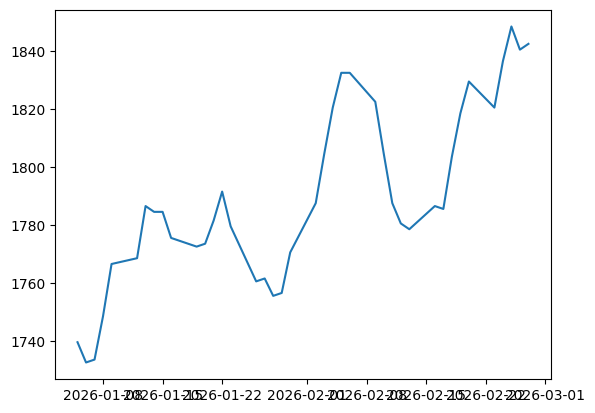

In [50]:
yen_test.iloc[-40:].plot()    

In [20]:
import pandas as pd
import os

folder = r"C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\systematic\realized_pnl"

dfs = []
for file in sorted(os.listdir(folder)):
    if file.endswith('.csv'):
        df = pd.read_csv(os.path.join(folder, file), index_col='Date', parse_dates=True)
        dfs.append(df)

realized_pnl = pd.concat(dfs).sort_index().fillna(0)

In [51]:
yen_test

2022-04-21     -19.5
2022-04-22      -7.5
2022-04-25     -12.5
2022-04-26     -27.5
2022-04-27     -20.5
               ...  
2026-02-23    1820.5
2026-02-24    1836.5
2026-02-25    1848.5
2026-02-26    1840.5
2026-02-27    1842.5
Name: signal, Length: 1000, dtype: float64

In [34]:
temp = PerfA.get_trade_hist().reset_index()
temp.groupby('index')[['profit','commission','swap','fee']].sum()["2026-01-01":].cumsum()#.plot()

,profit,commission,swap,fee
index,,,,
2026-01-01,7.04,0.00,-4.61,0.0
2026-01-02,320.58,0.00,-7.75,0.0
2026-01-03,227.70,0.00,-8.42,0.0
2026-01-05,227.70,0.00,-8.42,0.0
2026-01-06,411.41,-3.80,-35.54,0.0
2026-01-07,129.36,-4.08,-39.51,0.0
2026-01-08,-291.57,-4.08,-40.05,0.0
2026-01-10,-264.72,-4.21,-40.18,0.0
2026-01-12,-218.57,-4.21,-51.60,0.0


In [308]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ──────────────────────────────────────────────
LOOKBACK  = 20    # rolling window for mean/std
Z_THRESH  = 1.0   # z-score threshold to enter trade

# ── Data ────────────────────────────────────────────────────
btc  = yf.download("BTC-USD", start="2023-01-01", auto_adjust=True)['Close'].squeeze()
ibit = yf.download("IBIT",    start="2024-01-01", auto_adjust=True)['Close'].squeeze()

def mean_reversion_pnl(price, lookback=LOOKBACK, z_thresh=Z_THRESH, label=''):
    ma     = price.rolling(lookback).mean()
    std    = price.rolling(lookback).std()
    zscore = (price - ma) / std          # +ve = above mean, -ve = below mean

    signal = -np.sign(zscore)            # fade the move: short when above, long when below
    signal[abs(zscore) < z_thresh] = 0  # flat if not extreme enough

    daily_ret = price.pct_change()
    strat_ret = signal.shift(1) * daily_ret  # shift to avoid look-ahead

    cum = (1 + strat_ret).cumprod()

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    price.plot(ax=axes[0], label='Price')
    ma.plot(ax=axes[0], label=f'{lookback}d MA', linestyle='--')
    axes[0].set_title(f'{label} — Price vs MA')
    axes[0].legend()

    zscore.plot(ax=axes[1], color='purple')
    axes[1].axhline( z_thresh, color='red',   linestyle='--', alpha=0.5)
    axes[1].axhline(-z_thresh, color='green', linestyle='--', alpha=0.5)
    axes[1].axhline(0, color='k', lw=0.5)
    axes[1].set_title('Z-score (entry when outside dashed lines)')

    cum.plot(ax=axes[2], color='orange')
    axes[2].axhline(1, color='k', lw=0.5)
    axes[2].set_title(f'Cumulative return — Sharpe: {strat_ret.mean()/strat_ret.std()*np.sqrt(252):.2f}')

    plt.tight_layout()
    plt.show()

    return signal, strat_ret

btc_signal,  btc_ret  = mean_reversion_pnl(btc,  label='BTC-USD')
ibit_signal, ibit_ret = mean_reversion_pnl(ibit, label='IBIT')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
C:\Users\kmavy\AppData\Local\Temp\ipykernel_34316\1653116648.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\kmavy\AppData\Local\Temp\ipykernel_34316\1653116648.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


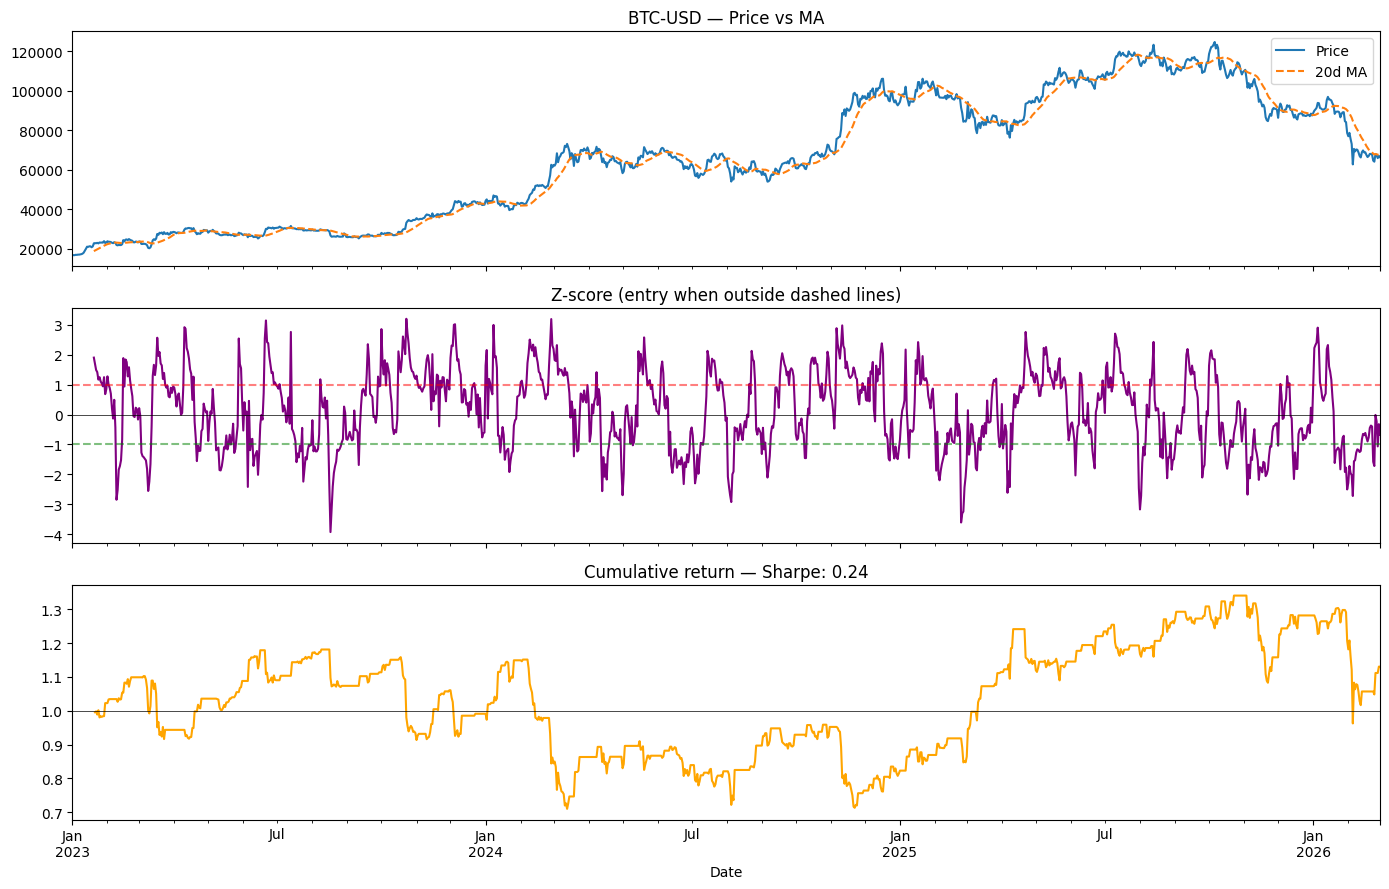

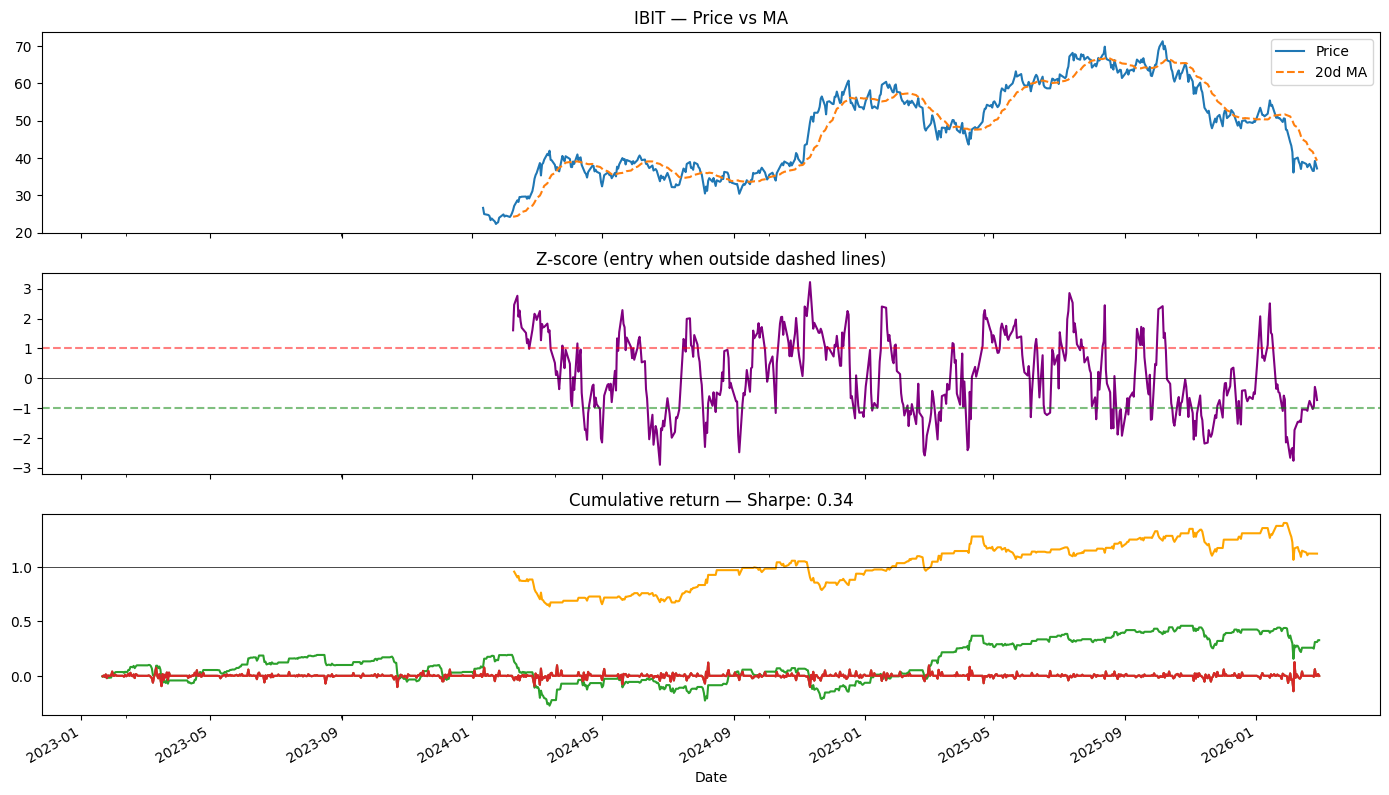

In [315]:
btc_ret.plot()
plt.show()

In [312]:
%matplotlib inline 

In [314]:
btc_ret.cumsum().plot()

<Axes: title={'center': 'Cumulative return — Sharpe: 0.34'}, xlabel='Date'>

In [10]:
realized_pnl[['TOTAL']].cumsum().plot()

NameError: name 'realized_pnl' is not defined

In [ ]:

# --- Backtest vs Realized USDJPY diagnostic ---

# 1. Proper backtest PnL: signal * hourly price change (in pips)
yen_full = get_usdjpy_signal()
backtest_hourly = yen_full['signal'].shift() * yen_full['close'].diff()  # pips per hour
backtest_daily = backtest_hourly.groupby(yen_full.index.date).sum()
backtest_daily.index = pd.to_datetime(backtest_daily.index)

# 2. Realized daily PnL from actual trades
usdjpy_trades = dollayenrlsd[dollayenrlsd['type'] == 1].copy()  # closes only
usdjpy_trades.index = pd.to_datetime(usdjpy_trades.index)
realized_daily = usdjpy_trades['profit'].groupby(usdjpy_trades.index.date).sum()
realized_daily.index = pd.to_datetime(realized_daily.index)

# 3. Align to common date range
start = max(backtest_daily.index.min(), realized_daily.index.min())
end   = min(backtest_daily.index.max(), realized_daily.index.max())
bt = backtest_daily.loc[start:end]
rd = realized_daily.reindex(bt.index, fill_value=0)

# 4. Normalize backtest to USD: scale so total matches realized total
# (exposes timing/direction diffs without sizing noise)
scale = rd.sum() / bt.sum() if bt.sum() != 0 else 1
bt_scaled = bt * scale

# 5. Plot cumulative comparison
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

pd.concat({'Backtest (scaled)': bt_scaled.cumsum(), 'Realized': rd.cumsum()}, axis=1).plot(ax=axes[0])
axes[0].set_title('Cumulative PnL: Backtest vs Realized USDJPY')
axes[0].set_ylabel('USD')
axes[0].axhline(0, color='black', linewidth=0.5)

# Daily difference
diff = rd - bt_scaled
diff.plot(ax=axes[1], color='red', alpha=0.6)
axes[1].set_title('Daily Difference (Realized - Backtest)')
axes[1].set_ylabel('USD')
axes[1].axhline(0, color='black', linewidth=0.5)

# Signal alignment: are they at least going in the same direction?
direction_match = np.sign(bt) == np.sign(rd)
direction_match_pct = direction_match.mean() * 100
direction_match.astype(int).rolling(10).mean().plot(ax=axes[2], color='green')
axes[2].set_title(f'Direction Agreement (10d rolling) — overall {direction_match_pct:.1f}% match')
axes[2].set_ylabel('Fraction matching')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# 6. Summary stats
print("\n=== Summary ===")
print(f"Backtest total (pips):   {bt.sum():.1f}")
print(f"Realized total (USD):    {rd.sum():.1f}")
print(f"Scale factor (USD/pip):  {scale:.4f}")
print(f"Direction match:         {direction_match_pct:.1f}%")
print(f"\nDays with big divergence (|diff| > 100 USD):")
print(diff[abs(diff) > 100].sort_values().to_string())
